In [1]:
from river_model import RiverModel
from bayes_estimator import DAExperiment
from sensitivity_analysis import SensitivityAnalysisRiver

In [2]:
from constants import N_SIZE_NETWORK, MAT_NETWORK, N_LONGEST_PATH

In [3]:
from constants import D_T, N_ITER, VEC_T
from constants import QIN_TS, Q_T0

In [4]:
from constants import VEC_TOBS

## Model

Explications, illustration ...

In [6]:
forward_model = RiverModel(par_k_in = 0.5, par_x_in = 0.3)

### State variables : Q

In [7]:
q_out_ts = forward_model.run()

### Diagnostic variables : H

Known law relating Q and H

In [8]:
h_out_ts = forward_model.estimate_height(q_out_ts)

/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/river_model.py:229: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(mat_q_in_ts[k,:], "--k", color=(0.0, 0.0, 0.75), linewidth=0.75, label="Qin")
/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/river_model.py:236: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-b" (-> color='b'). The keyword argument will take precedence.
  ax_bis.plot(h_out_ts[k, :], "-b", color=(0.75, 0., 0.75), label="Hout")


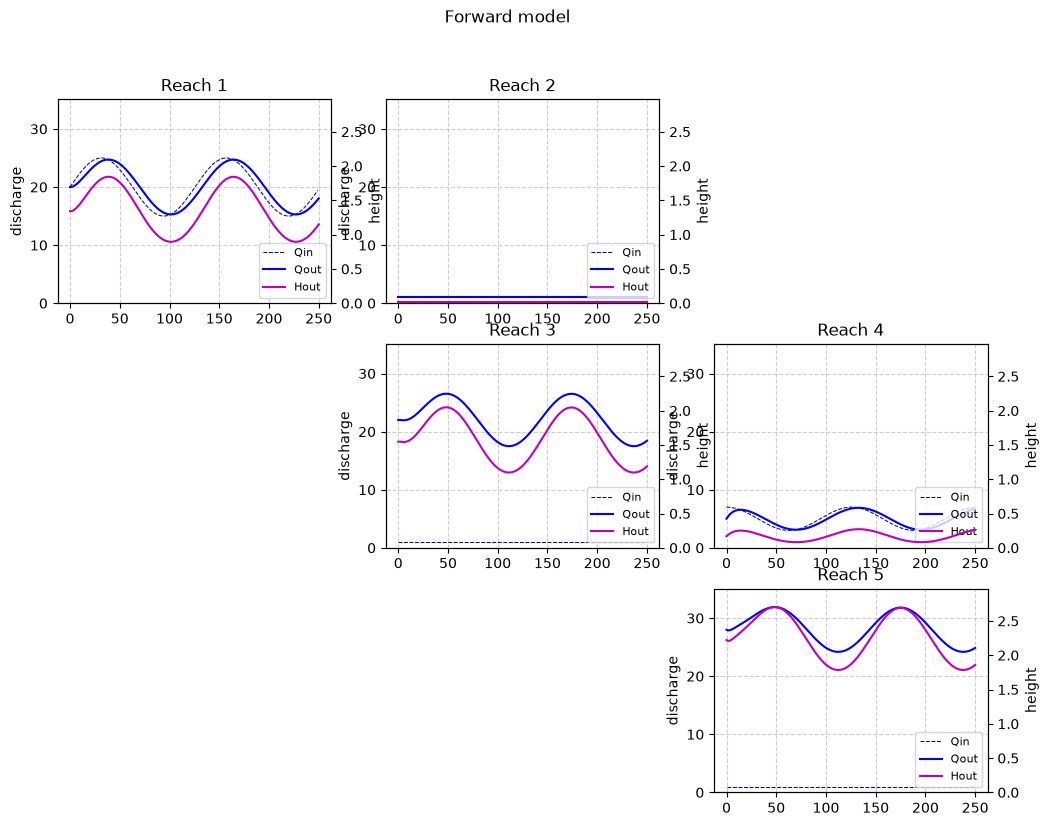

In [9]:
forward_model.plot(q_out_ts, h_out_ts, title="Forward model")

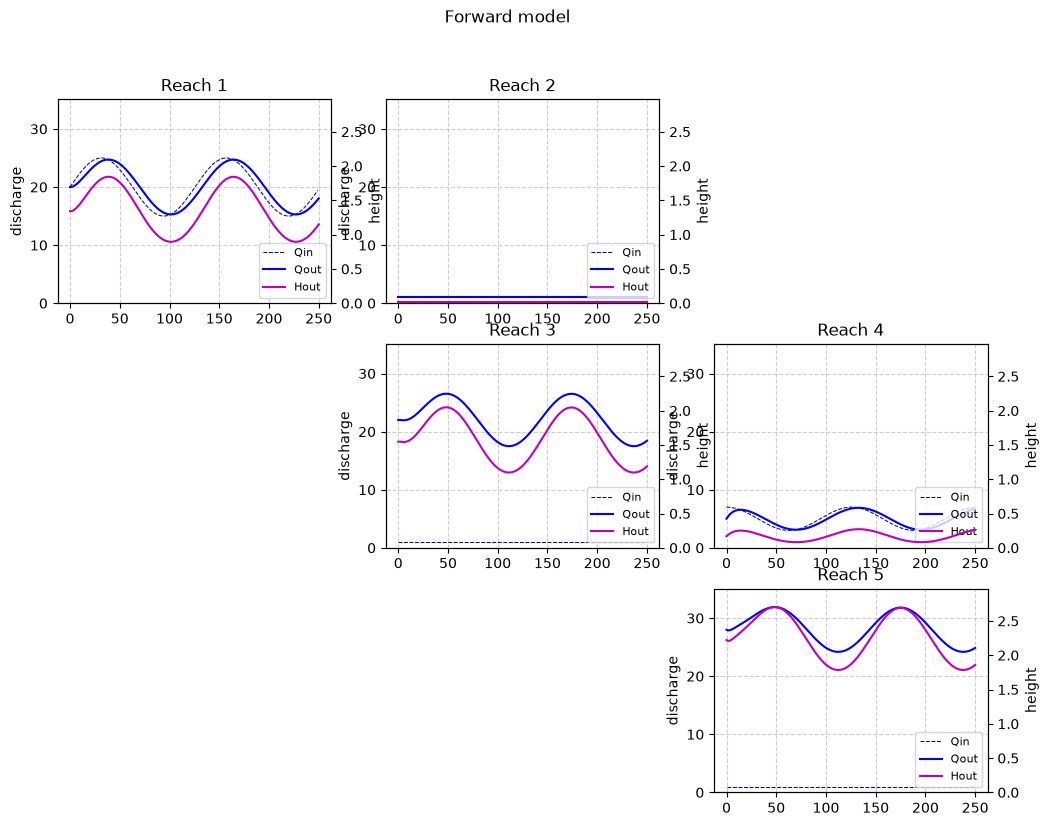

In [10]:
# Play with the model

k = 1.2 # Must be in [0.5, 1.5]
x = 0.3 # Must be in [0.1, 0.3]
qin_mul = 1.5 # Must be in [0.25, 1.5]

test_model = RiverModel(par_k_in = k, par_x_in = x, par_qin_mul=qin_mul)
q_out_ts = forward_model.run()
h_out_ts = forward_model.estimate_height(q_out_ts)
forward_model.plot(q_out_ts, h_out_ts, title="Forward model")

## Observations

### Available observations set

In [11]:
dct_obs_1 = {
    "yobs": [ 28.031, 31.354, 28.918, 26.057, 25.365, 26.536, 29.751, 30.046, 26.028, 26.167 ],
    "variable": "q",
    "reach": [5]
}

In [12]:
dct_obs_2 = {
    "yobs": [ 2.345, 2.594, 2.340, 2.028, 1.921, 2.086, 2.391, 2.312, 2.029, 1.949 ],
    "variable": "h",
    "reach": [5]
}

In [13]:
dct_obs_3 = {
    "yobs": [ 21.910, 26.992, 24.554, 19.885, 17.863, 19.427, 26.036, 23.850, 20.655, 19.492 ],
    "variable": "q",
    "reach": [3]
}

### Model vs observations

/work/CAMPUS/users/emerych/git/VSEO-6-Training-Sessions-Data-Assimilation/bayes_estimator.py:72: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-b" (-> color='b'). The keyword argument will take precedence.
  ax_bis.plot(h_out_ts[k, :], "-b", color=(0.75, 0., 0.75), label="H free run")


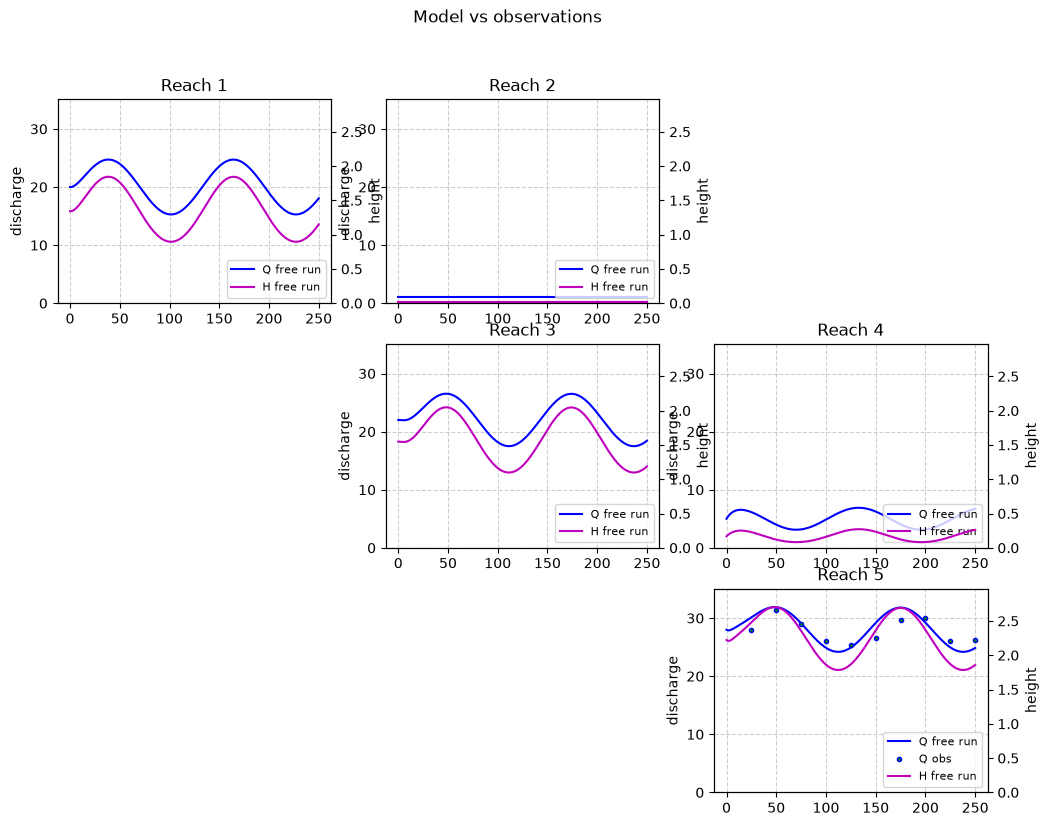

In [14]:
assim_base = DAExperiment(forward_model=forward_model,
                        dct_obs=dct_obs_1)
assim_base.plot_model_vs_obs()

### [Bonus #1] Sensitivity analysis - focus on (k,x) parameters

In [ ]:
my_analysis = SensitivityAnalysisRiver()
my_analysis.generate_sample()
my_analysis.generate_outputs_ensemble()
my_analysis.estimate_sobol_ensemble()
my_analysis.plot_sensitivity_indices()

### [Bonus #2] Sensitivity analysis - (k,x) parameters + inflow

In [ ]:
my_analysis = SensitivityAnalysisRiver(bool_qin=True)
my_analysis.generate_sample()
my_analysis.generate_outputs_ensemble()
my_analysis.estimate_sobol_ensemble()
my_analysis.plot_sensitivity_indices()

## Build your data assimilation experiment
### Control : what we want to correct = what is the most uncertain in the model // which inputs the observations can help correct
- state estimation -> directly correct the model state == model initial condition
- parameter estimation -> correct model parameters or inflow condition == model calibration
- "diagnostic" estimation -> like state estimation
### Observation : how the observations are related to the model state/diagnostic varaiables // the parameters

## State estimation

### Control

In [15]:
dct_ctl = {"experiment_type": "state", "variable": "q"}

### Observations

In [16]:
dct_obs = dct_obs_1

### Sequential state estimation - 3 steps

#### 1. propagation

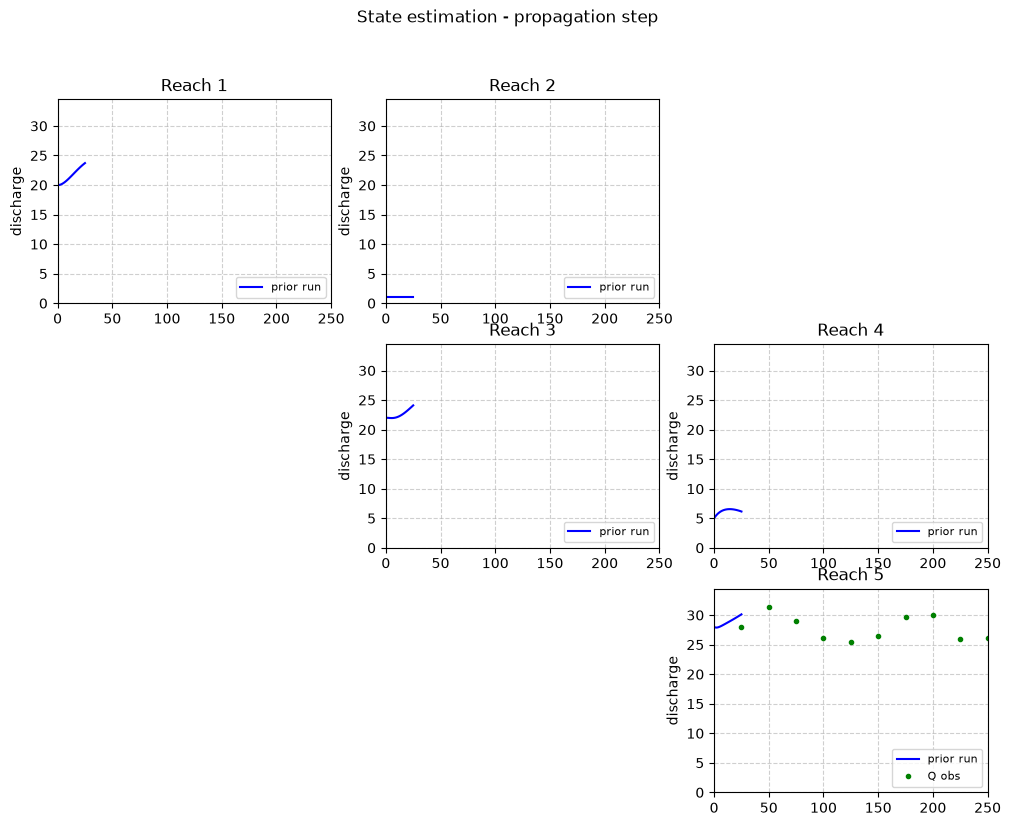

In [17]:
state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs, dct_ctl=dct_ctl)
xb, qb_run = state_assim.perform_state_estimation_propagation()

#### 2. analysis

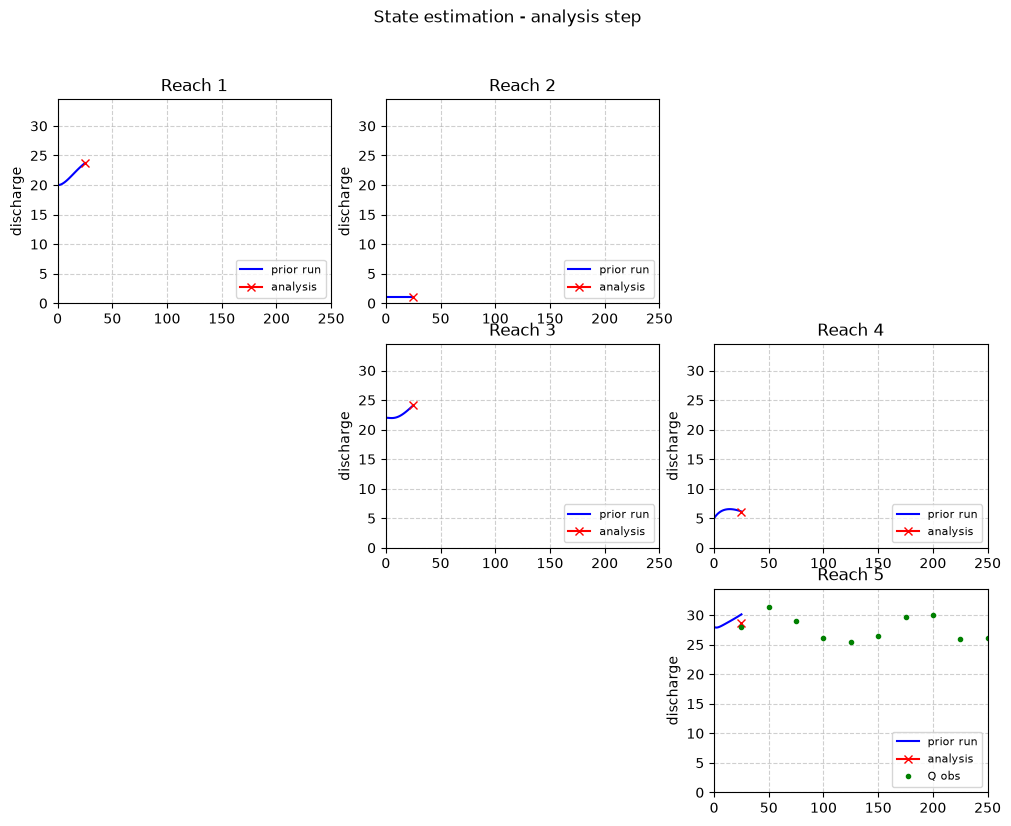

In [18]:
# Play with sig_o & sig_b value
state_assim.sig_o = 0.5
state_assim.sig_b = 0.75
xa = state_assim.perform_state_estimation_analysis(xb=xb, q_run=qb_run)

#### 3. cycling

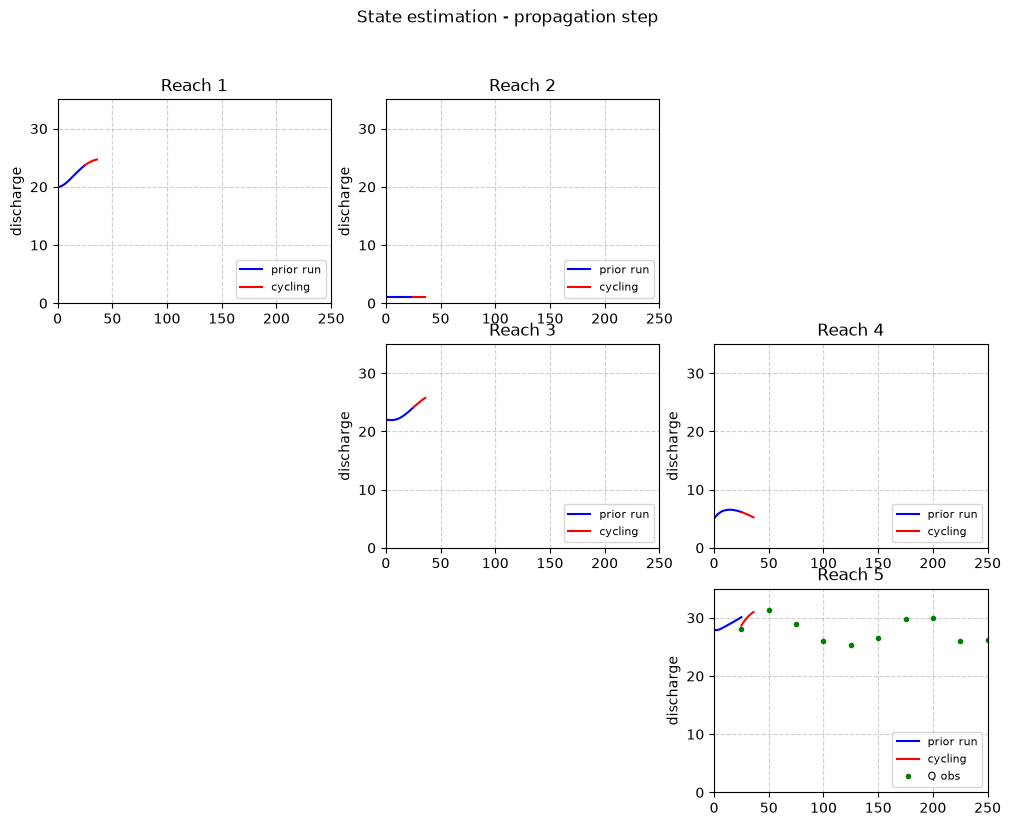

In [19]:
state_assim.perform_state_estimation_cycling(xa=xa)

## Full experiment : play with uncertainties values & observation vector

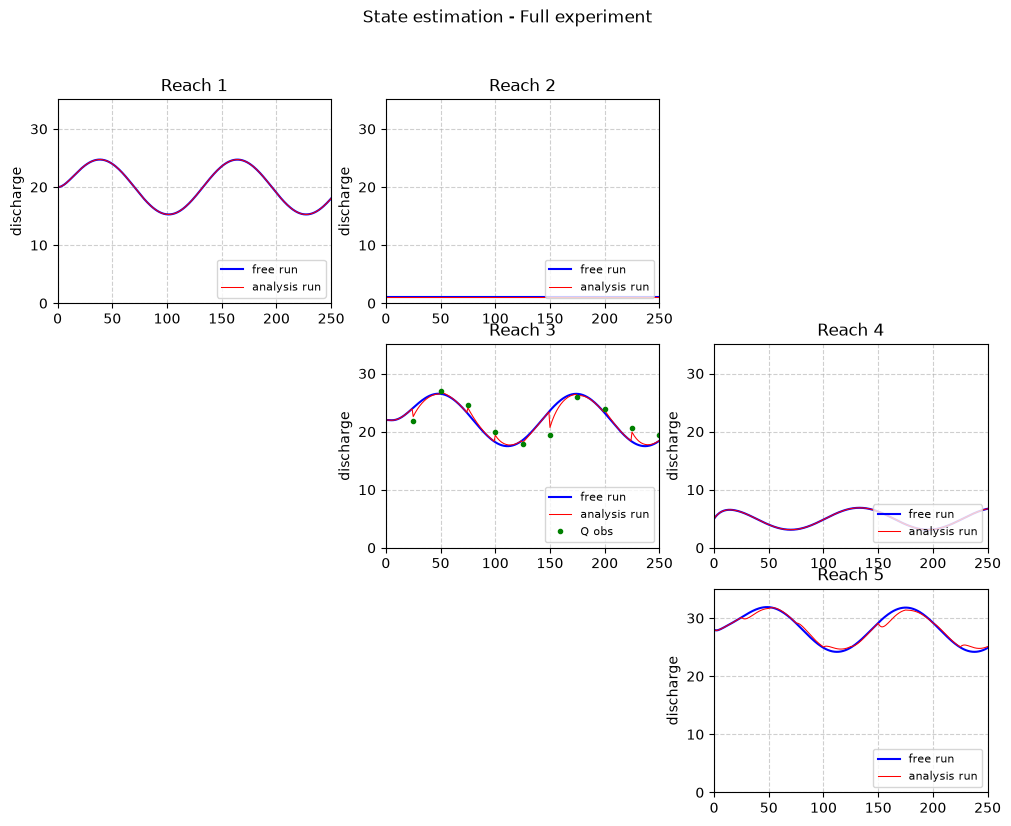

In [20]:
sig_b = 0.75
sig_o = 0.5
dct_obs = dct_obs_3 # dct_obs_3

state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs, dct_ctl=dct_ctl)
state_assim.sig_o = sig_o
state_assim.sig_b = sig_b
state_assim.perform_assim()
## Ajouter calcul de statistiques

### [Bonus ] propagation de la correction dans le réseau

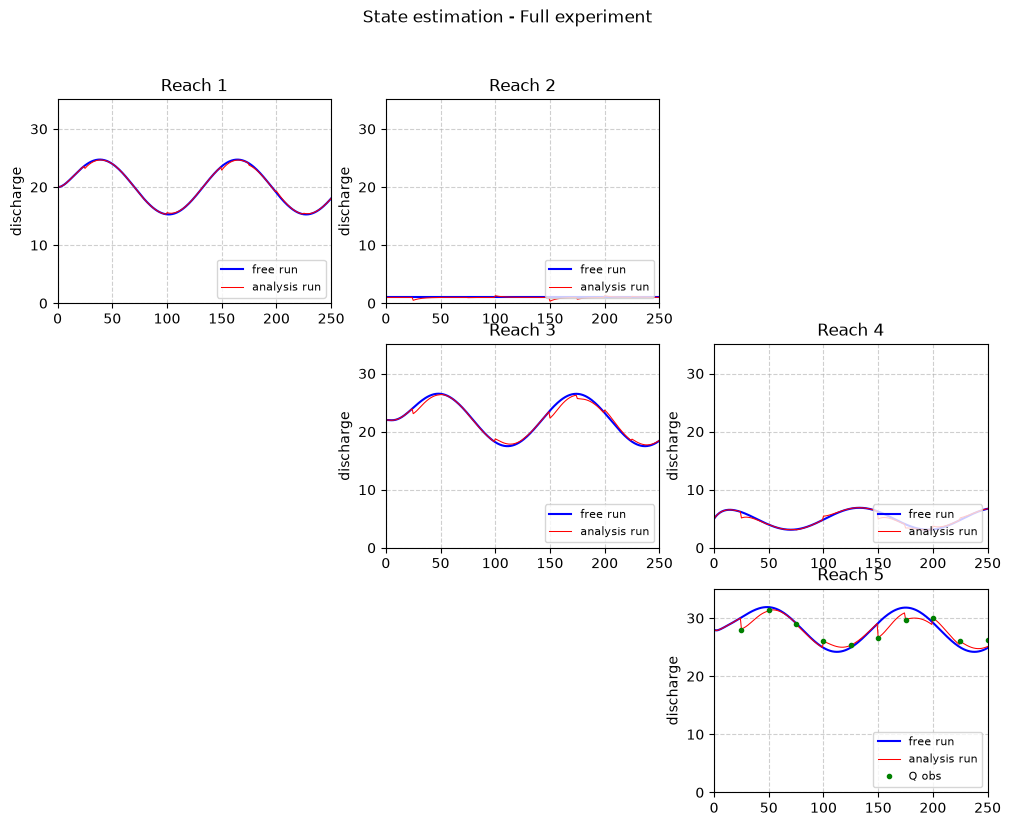

In [22]:
from constants import SIG_B_Q, SIG_O_Q
import numpy as np
B_in = np.array([
        [SIG_B_Q**2., 0., 0., 0., SIG_B_Q**2.*0.25],
        [0., SIG_B_Q**2., 0., 0., SIG_B_Q**2.*0.25],
        [0., 0., SIG_B_Q**2., 0., SIG_B_Q**2.*0.5],
        [0., 0., 0., SIG_B_Q**2., SIG_B_Q**2.*0.5],
        [SIG_B_Q**2.*0.25, SIG_B_Q**2.*0.25, SIG_B_Q**2.*0.5, SIG_B_Q**2.*0.5, SIG_B_Q**2.]
    ])
state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_1, dct_ctl=dct_ctl)
state_assim.sig_o = 0.1
state_assim.sig_b = 3.0
state_assim.perform_assim(b_in=B_in)

## Parameter estimation

### Control

In [23]:
dct_ctl = {"experiment_type": "parameter", "variable": "k"}

### Observations

In [24]:
dct_obs = dct_obs_1

### Sequential parameter estimation

#### Propagation

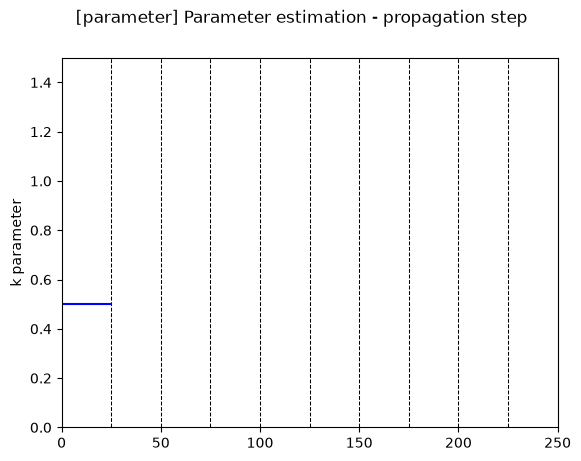

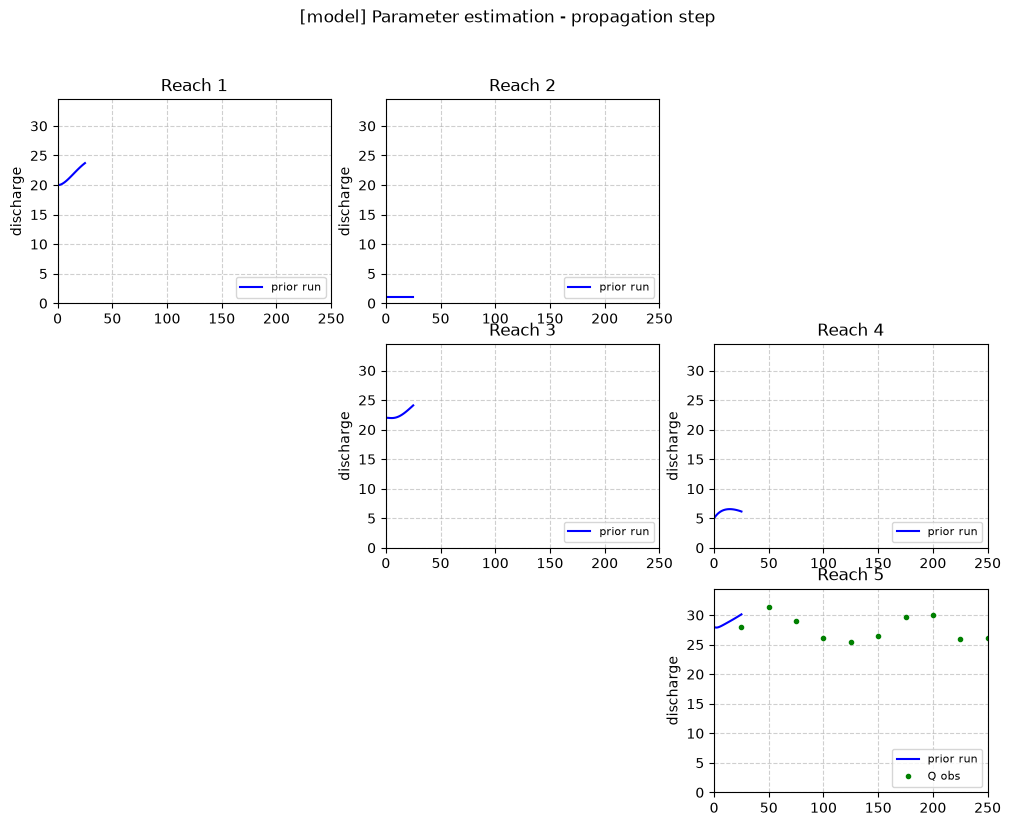

In [26]:
my_assim = DAExperiment(forward_model=forward_model,
                            dct_obs=dct_obs_1,
                            dct_ctl=dct_ctl)
xb, qb_run = my_assim.perform_parameter_estimation_propagation()

#### Analysis

0.5 0.3768137533436172


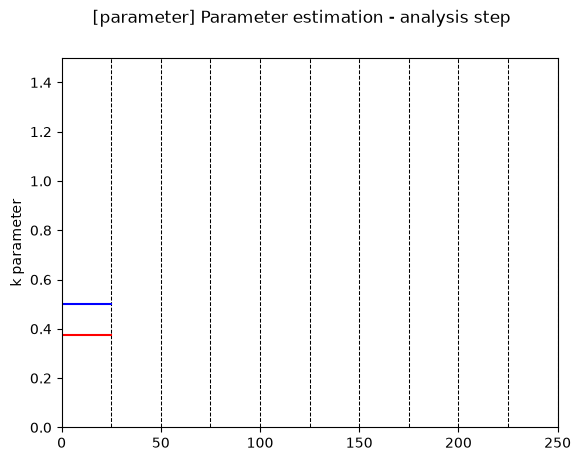

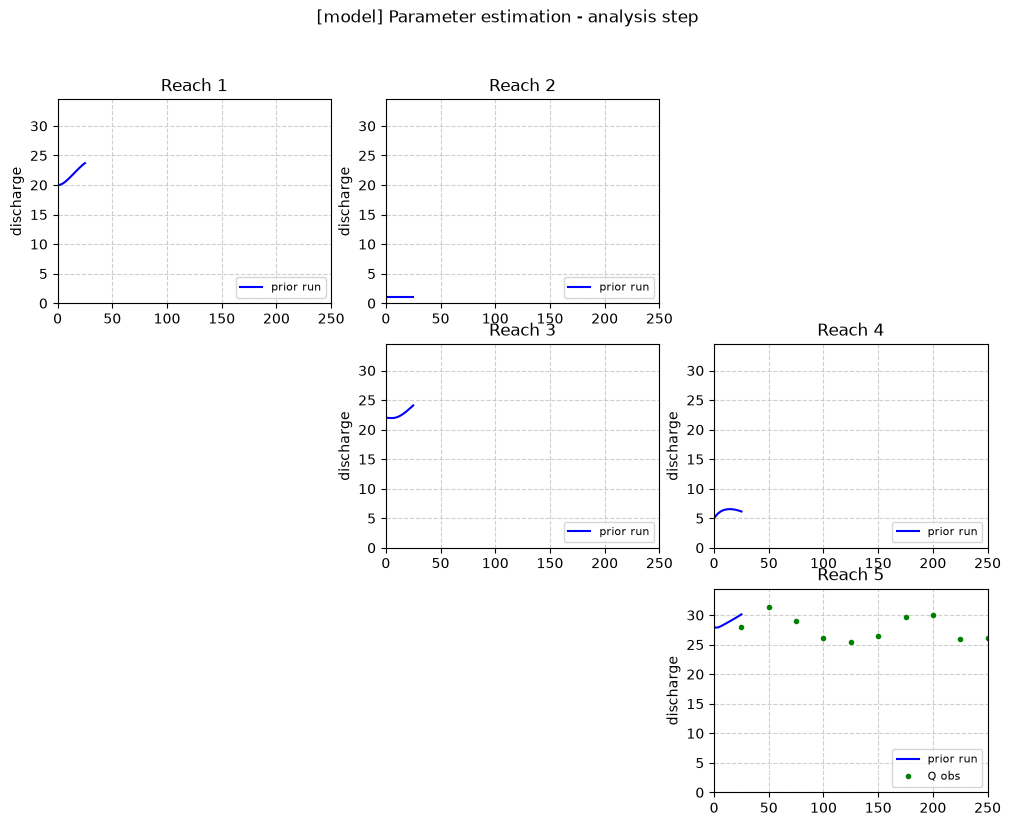

In [31]:
my_assim.sig_o = 1.0
my_assim.sig_b = 0.25
xa = my_assim.perform_parameter_estimation_analysis(xb=xb, q_run=qb_run)

#### Cycling

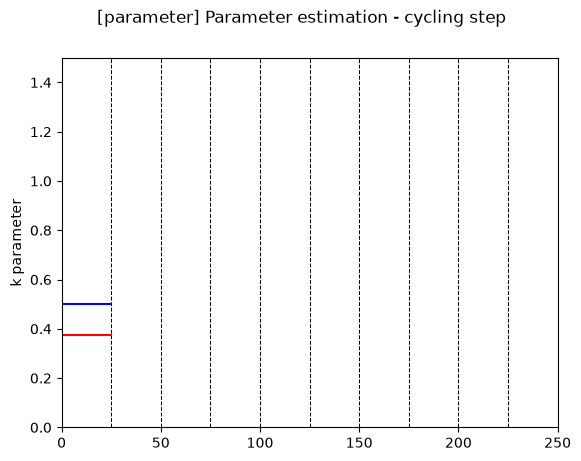

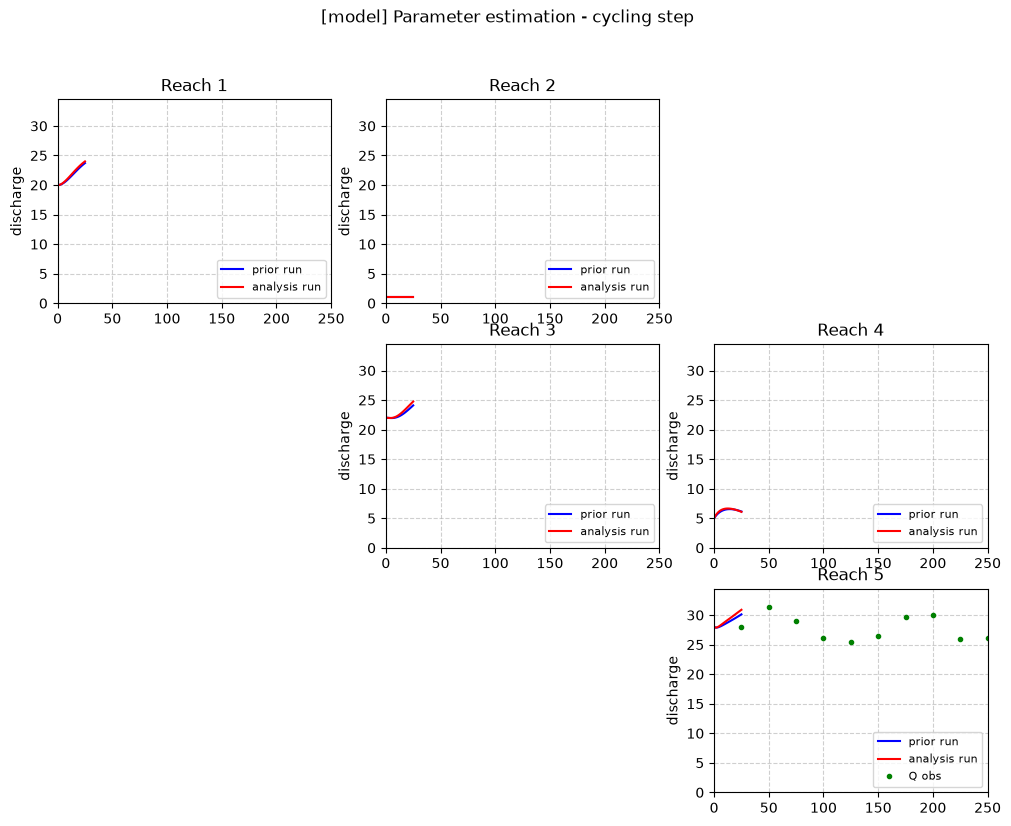

In [32]:
my_assim.perform_parameter_estimation_cycling(xb=xb, xa=xa, q_run=qb_run)

## Full experiment : play with uncertainties values & observation vector

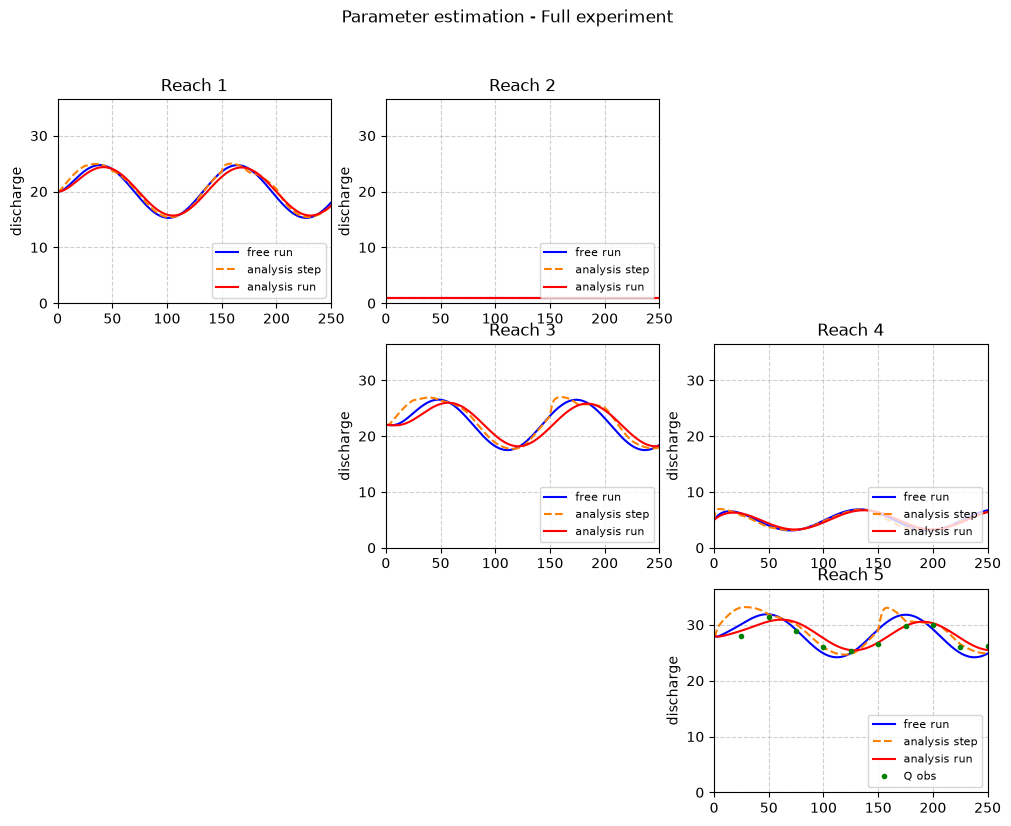

In [39]:
dct_ctl = {"experiment_type": "parameter", "variable": "k"}
my_assim = DAExperiment(forward_model=forward_model,
                            dct_obs=dct_obs_1,
                            dct_ctl=dct_ctl)
my_assim.sig_o = 0.5
my_assim.sig_b = 0.25
my_assim.perform_assim()